In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
acl_df = pd.read_csv("../data/processed/acl_analysis.csv")

In [3]:
acl_df["date_ami"] = pd.to_datetime(acl_df["date_ami"], errors="coerce")

In [4]:
analysis_df = acl_df.dropna(subset=["score_pct", "tsk_11"]).copy()
analysis_df.shape

(430, 8)

In [5]:
X = analysis_df[["tsk_11"]]
y = analysis_df["score_pct"]

In [6]:
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.22]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['tsk_11']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,69.13
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [7]:
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])
print("R²:", model.score(X, y))

Intercept: 69.12805683315067
Slope: 0.21685803991434024
R²: 0.015065709299233343


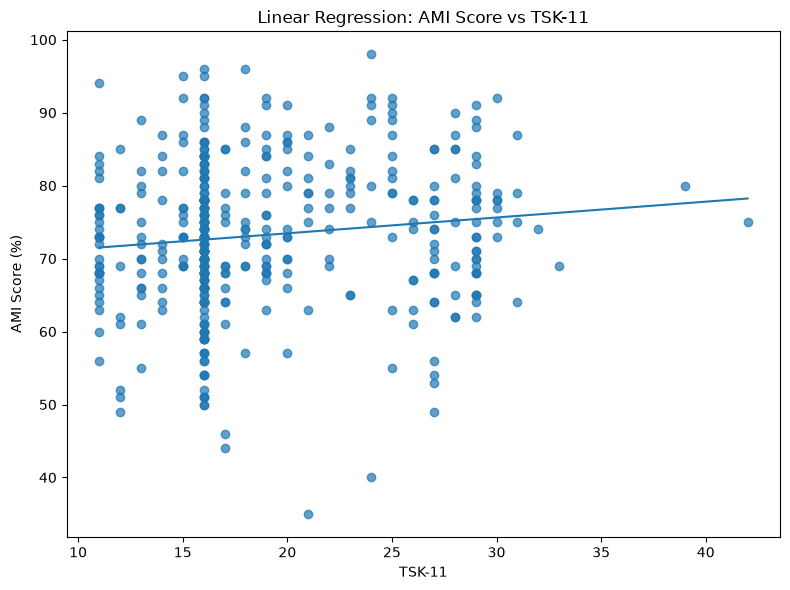

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(analysis_df["tsk_11"], analysis_df["score_pct"], alpha=0.7)

x_line = pd.DataFrame({"tsk_11": sorted(analysis_df["tsk_11"])})
y_line = model.predict(x_line)

plt.plot(x_line["tsk_11"], y_line)

plt.xlabel("TSK-11")
plt.ylabel("AMI Score (%)")
plt.title("Linear Regression: AMI Score vs TSK-11")

plt.tight_layout()
plt.show()

In [9]:
plt.savefig("../figures/regression_model.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>